# TF-IDF + Random Forest Model

Build and tune a sentiment classification model using TF-IDF vectorization and Random Forest.

**Approach**:
- TF-IDF vectorizer with bigrams and 10K features
- Optuna hyperparameter tuning (n_estimators, max_depth, min_samples_split, class_weight)
- Evaluation: confusion matrix, ROC curves, classification report
- Feature importance and SHAP interpretability

## Imports

In [1]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, auc, f1_score, accuracy_score)
from sklearn.preprocessing import label_binarize
import optuna
from optuna.samplers import TPESampler
import joblib
import shap
import os
from io import StringIO
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print('All imports successful')

All imports successful


## Helper Classes

In [2]:
class TfidfRandomForestModel:
    """TF-IDF + Random Forest model for sentiment analysis."""
    
    def __init__(self, str_bucket, str_dirname_output):
        self.str_bucket = str_bucket
        self.str_dirname_output = str_dirname_output
        self.s3_client = boto3.client('s3', region_name='us-east-1')
        self.X_train = None
        self.X_val = None
        self.X_test = None
        self.y_train = None
        self.y_val = None
        self.y_test = None
        self.vectorizer = None
        self.model = None
        self.dict_best_params = None
        self.set_plot_style()
    
    def set_plot_style(self):
        sns.set_style('whitegrid')
        plt.rcParams['figure.figsize'] = (14, 6)
        plt.rcParams['font.size'] = 10
    
    def import_data(self):
        """Load train/validation/test splits from S3."""
        dict_splits = {}
        list_split_names = ['train', 'validation', 'test']
        
        for str_split in list_split_names:
            str_uri = f's3://{self.str_bucket}/02_preprocessing/{str_split}_split.parquet'
            dict_splits[str_split] = pd.read_parquet(str_uri)
        
        self.X_train = dict_splits['train']['review_text_clean']
        self.y_train = dict_splits['train']['sentiment_3class']
        self.X_val = dict_splits['validation']['review_text_clean']
        self.y_val = dict_splits['validation']['sentiment_3class']
        self.X_test = dict_splits['test']['review_text_clean']
        self.y_test = dict_splits['test']['sentiment_3class']
        
        print(f'Loaded data splits')
        print(f'  Train: {len(self.X_train):,} | Val: {len(self.X_val):,} | Test: {len(self.X_test):,}')
        return True
    
    def build_tfidf(self, int_max_features=3000, tuple_ngram_range=(1, 2)):
        """Build and fit TF-IDF vectorizer."""
        print(f'\nBuilding TF-IDF vectorizer...')
        self.vectorizer = TfidfVectorizer(
            max_features=int_max_features,
            ngram_range=tuple_ngram_range,
            min_df=2,
            max_df=0.95,
            lowercase=True,
            sublinear_tf=True
        )
        
        # Fit on training data
        self.X_train_tfidf = self.vectorizer.fit_transform(self.X_train)
        self.X_val_tfidf = self.vectorizer.transform(self.X_val)
        self.X_test_tfidf = self.vectorizer.transform(self.X_test)
        
        print(f'TF-IDF vectorizer fitted')
        print(f'  Vocabulary size: {len(self.vectorizer.get_feature_names_out())}')
        print(f'  Train shape: {self.X_train_tfidf.shape}')
    
    def tune_model(self, int_n_trials=20):
        """Optuna hyperparameter tuning for Random Forest."""
        print(f'\nStarting Optuna tuning ({int_n_trials} trials)...')
        
        def objective(trial):
            int_n_estimators = trial.suggest_int('n_estimators', 50, 150, step=10)
            int_max_depth = trial.suggest_int('max_depth', 10, 50)
            int_min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
            int_min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
            str_class_weight = trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample'])
            
            try:
                cls_model = RandomForestClassifier(
                    n_estimators=int_n_estimators,
                    max_depth=int_max_depth,
                    min_samples_split=int_min_samples_split,
                    min_samples_leaf=int_min_samples_leaf,
                    class_weight=str_class_weight,
                    random_state=42,
                    n_jobs=-1
                )
                cls_model.fit(self.X_train_tfidf, self.y_train)
                y_pred = cls_model.predict(self.X_val_tfidf)
                flt_f1_macro = f1_score(self.y_val, y_pred, average='macro', zero_division=0)
                return flt_f1_macro
            except Exception as e:
                return 0.0
        
        sampler = TPESampler(seed=42)
        study = optuna.create_study(direction='maximize', sampler=sampler)
        study.optimize(objective, n_trials=int_n_trials, show_progress_bar=True)
        
        self.dict_best_params = study.best_params
        flt_best_score = study.best_value
        
        print(f'\nTuning complete')
        print(f'  Best validation F1-macro: {flt_best_score:.4f}')
        print(f'  Best parameters: {self.dict_best_params}')
    
    def train_final_model(self):
        """Train final model with best hyperparameters."""
        print(f'\nTraining final model...')
        
        self.model = RandomForestClassifier(
            n_estimators=self.dict_best_params['n_estimators'],
            max_depth=self.dict_best_params['max_depth'],
            min_samples_split=self.dict_best_params['min_samples_split'],
            min_samples_leaf=self.dict_best_params['min_samples_leaf'],
            class_weight=self.dict_best_params['class_weight'],
            random_state=42,
            n_jobs=-1
        )
        
        self.model.fit(self.X_train_tfidf, self.y_train)
        print(f'Model trained successfully')
    
    def evaluate(self):
        """Evaluate model on test set."""
        y_pred = self.model.predict(self.X_test_tfidf)
        y_proba = self.model.predict_proba(self.X_test_tfidf)
        
        print('\n' + '='*70)
        print('TEST SET EVALUATION - RANDOM FOREST + TF-IDF')
        print('='*70)
        
        flt_accuracy = accuracy_score(self.y_test, y_pred)
        print(f'\nAccuracy: {flt_accuracy:.4f}')
        
        # F1 scores
        flt_f1_macro = f1_score(self.y_test, y_pred, average='macro', zero_division=0)
        flt_f1_weighted = f1_score(self.y_test, y_pred, average='weighted', zero_division=0)
        print(f'F1-Macro: {flt_f1_macro:.4f}')
        print(f'F1-Weighted: {flt_f1_weighted:.4f}')
        
        # ROC AUC
        y_bin = label_binarize(self.y_test, classes=[0, 1, 2])
        flt_roc_auc = roc_auc_score(y_bin, y_proba, multi_class='ovr', average='macro')
        print(f'ROC AUC (macro): {flt_roc_auc:.4f}')
        
        print(f'\nClassification Report:')
        print(classification_report(self.y_test, y_pred,
                                   target_names=['Negative', 'Neutral', 'Positive'],
                                   zero_division=0))
        
        return y_pred, y_proba
    
    def plot_confusion_matrix(self, y_pred):
        """Plot and save confusion matrix."""
        cm = confusion_matrix(self.y_test, y_pred)
        
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
                   xticklabels=['Negative', 'Neutral', 'Positive'],
                   yticklabels=['Negative', 'Neutral', 'Positive'],
                   cbar_kws={'label': 'Count'})
        ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
        ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
        ax.set_title('Confusion Matrix - Random Forest + TF-IDF', fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/01_confusion_matrix.png', bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 01_confusion_matrix.png')
    
    def plot_roc_curves(self, y_proba):
        """Plot one-vs-rest ROC curves."""
        y_bin = label_binarize(self.y_test, classes=[0, 1, 2])
        list_colors = ['#d62728', '#ff7f0e', '#2ca02c']
        list_labels = ['Negative', 'Neutral', 'Positive']
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        for int_i in range(3):
            fpr, tpr, _ = roc_curve(y_bin[:, int_i], y_proba[:, int_i])
            flt_auc = auc(fpr, tpr)
            ax.plot(fpr, tpr, color=list_colors[int_i], lw=2,
                   label=f'{list_labels[int_i]} (AUC = {flt_auc:.3f})')
        
        ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
        ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
        ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
        ax.set_title('ROC Curves - Random Forest + TF-IDF', fontsize=14, fontweight='bold')
        ax.legend(loc='lower right', fontsize=10)
        ax.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/02_roc_curves.png', bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 02_roc_curves.png')
    
    def plot_feature_importance(self, int_top_n=20):
        """Plot top features from Random Forest."""
        list_feature_names = self.vectorizer.get_feature_names_out()
        arr_importances = self.model.feature_importances_
        list_top_idx = np.argsort(arr_importances)[-int_top_n:][::-1]
        
        list_top_names = [list_feature_names[int_i] for int_i in list_top_idx]
        list_top_scores = arr_importances[list_top_idx]
        
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.barh(list_top_names, list_top_scores, color='seagreen', edgecolor='black')
        ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
        ax.set_title(f'Top {int_top_n} Features - Random Forest', fontsize=14, fontweight='bold')
        ax.invert_yaxis()
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/03_feature_importance.png', bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 03_feature_importance.png')
    
    def explain_with_shap(self, int_num_samples=100):
        """Generate SHAP explanations for model interpretability."""
        print(f'\nGenerating SHAP explanations...')
        X_test_sample = self.X_test_tfidf[:int_num_samples].toarray().astype(float)
        y_test_sample = self.y_test.iloc[:int_num_samples]
        
        explainer = shap.TreeExplainer(self.model)
        shap_values = explainer.shap_values(X_test_sample)
        
        list_feature_names = self.vectorizer.get_feature_names_out()
        
        print(f'SHAP values computed for {int_num_samples} samples')
        return shap_values, X_test_sample, list_feature_names
    
    def save_model(self):
        """Save vectorizer and model to disk."""
        str_vectorizer_path = f'{self.str_dirname_output}/tfidf_vectorizer.pkl'
        str_model_path = f'{self.str_dirname_output}/rf_model.pkl'
        
        joblib.dump(self.vectorizer, str_vectorizer_path)
        joblib.dump(self.model, str_model_path)
        
        print(f'\nModel saved')
        print(f'  Vectorizer: {str_vectorizer_path}')
        print(f'  Model: {str_model_path}')

## Constants

In [3]:
# S3 Configuration
str_bucket = 'nlp-sentiment-analysis-demo'
str_task = '04_tfidf_random_forest'
str_dirname_output = './output'

# Model parameters
int_tfidf_max_features = 3000
tuple_ngram_range = (1, 1)
int_optuna_trials = 10

## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
    print(f'✓ Created output directory: {str_dirname_output}')
except FileExistsError:
    print(f'✓ Output directory already exists: {str_dirname_output}')

✓ Output directory already exists: ./output


## Load Data and Build Model

In [5]:
# Initialize model class
cls_model = TfidfRandomForestModel(str_bucket, str_dirname_output)

# Load data
cls_model.import_data()

Loaded data splits
  Train: 18,168 | Val: 6,056 | Test: 6,057


True

In [6]:
# Build TF-IDF vectorizer
cls_model.build_tfidf(int_max_features=int_tfidf_max_features, tuple_ngram_range=tuple_ngram_range)


Building TF-IDF vectorizer...
TF-IDF vectorizer fitted
  Vocabulary size: 3000
  Train shape: (18168, 3000)


In [7]:
# Hyperparameter tuning
cls_model.tune_model(int_n_trials=int_optuna_trials)

[I 2026-03-22 02:43:58,388] A new study created in memory with name: no-name-db42ae57-5134-4c1a-bdb2-a0fdff90c077



Starting Optuna tuning (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

[I 2026-03-22 02:44:01,819] Trial 0 finished with value: 0.24897551832997425 and parameters: {'n_estimators': 90, 'max_depth': 48, 'min_samples_split': 15, 'min_samples_leaf': 6, 'class_weight': None}. Best is trial 0 with value: 0.24897551832997425.
[I 2026-03-22 02:44:07,621] Trial 1 finished with value: 0.2465367011974023 and parameters: {'n_estimators': 140, 'max_depth': 34, 'min_samples_split': 15, 'min_samples_leaf': 1, 'class_weight': None}. Best is trial 0 with value: 0.24897551832997425.
[I 2026-03-22 02:44:09,103] Trial 2 finished with value: 0.41182540567716064 and parameters: {'n_estimators': 70, 'max_depth': 17, 'min_samples_split': 7, 'min_samples_leaf': 6, 'class_weight': 'balanced_subsample'}. Best is trial 2 with value: 0.41182540567716064.
[I 2026-03-22 02:44:10,380] Trial 3 finished with value: 0.23826533158440832 and parameters: {'n_estimators': 60, 'max_depth': 21, 'min_samples_split': 8, 'min_samples_leaf': 5, 'class_weight': None}. Best is trial 2 with value: 0.4

In [8]:
# Train final model
cls_model.train_final_model()


Training final model...
Model trained successfully


## Evaluate Model

In [9]:
y_pred, y_proba = cls_model.evaluate()


TEST SET EVALUATION - RANDOM FOREST + TF-IDF

Accuracy: 0.4806
F1-Macro: 0.4142
F1-Weighted: 0.4815
ROC AUC (macro): 0.6113

Classification Report:
              precision    recall  f1-score   support

    Negative       0.26      0.41      0.32       830
     Neutral       0.33      0.27      0.30      1899
    Positive       0.63      0.62      0.63      3328

    accuracy                           0.48      6057
   macro avg       0.41      0.43      0.41      6057
weighted avg       0.49      0.48      0.48      6057



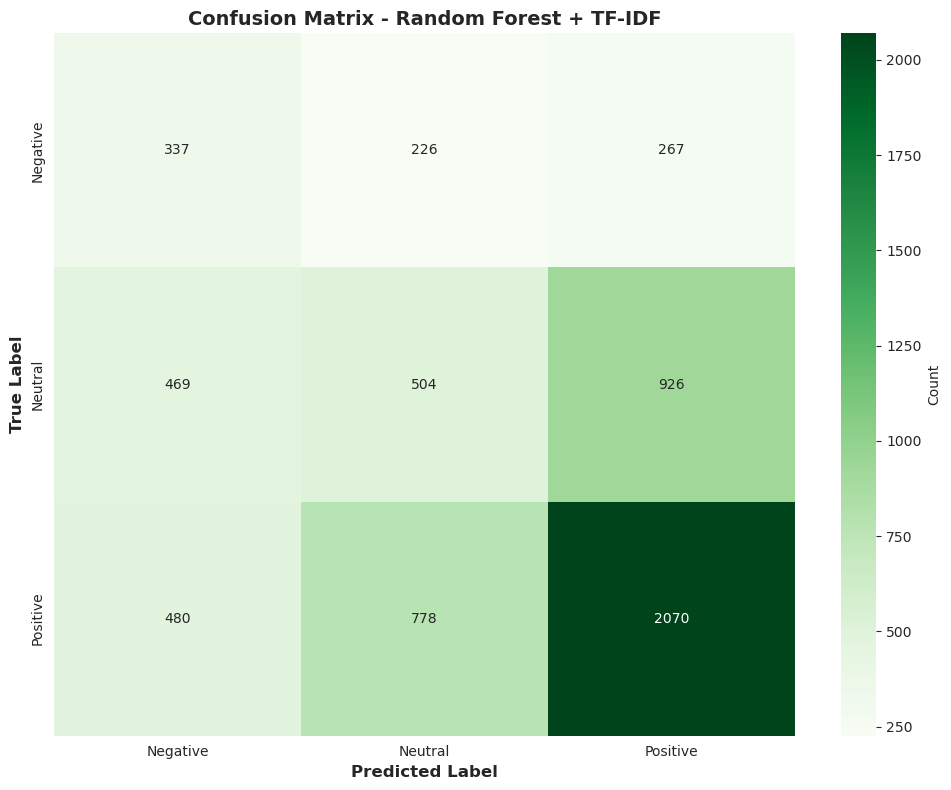

Saved: 01_confusion_matrix.png


In [10]:
# Visualizations
cls_model.plot_confusion_matrix(y_pred)

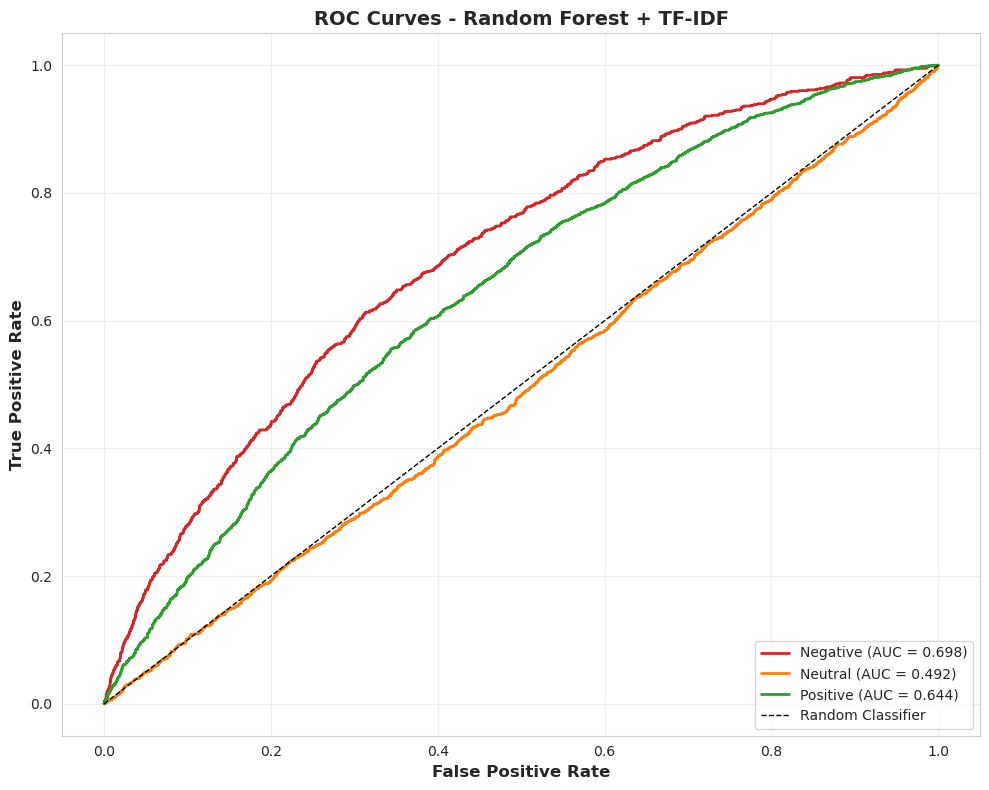

Saved: 02_roc_curves.png


In [11]:
cls_model.plot_roc_curves(y_proba)

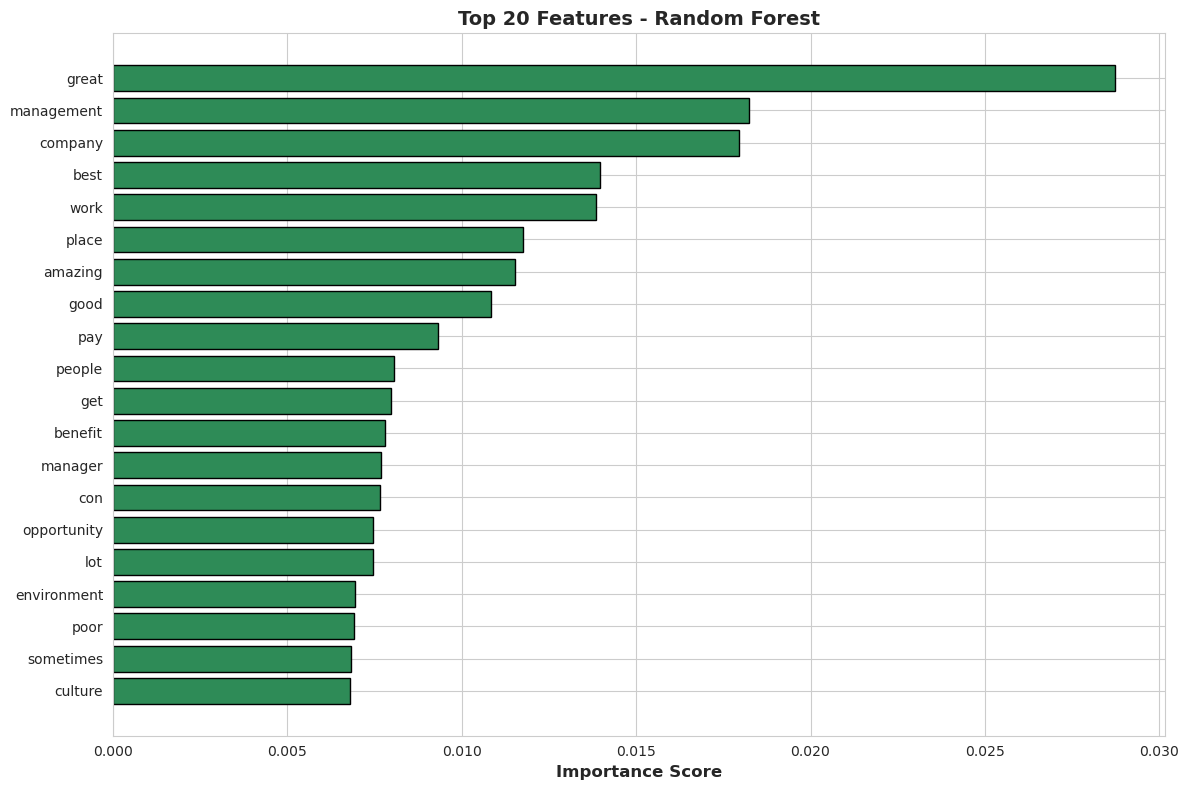

Saved: 03_feature_importance.png


In [12]:
cls_model.plot_feature_importance(int_top_n=20)

In [13]:
# SHAP explanations
shap_values, X_sample, list_features = cls_model.explain_with_shap(int_num_samples=100)


Generating SHAP explanations...
SHAP values computed for 100 samples


In [14]:
# Save model
cls_model.save_model()


Model saved
  Vectorizer: ./output/tfidf_vectorizer.pkl
  Model: ./output/rf_model.pkl


In [15]:
print('\n' + '='*70)
print('RANDOM FOREST + TF-IDF COMPLETE')
print('='*70)
print(f'\nModel Configuration:')
print(f'  Vectorizer: TF-IDF')
print(f'  Max features: {int_tfidf_max_features:,}')
print(f'  N-gram range: {tuple_ngram_range}')
print(f'  Classifier: Random Forest')
print(f'  Hyperparameter tuning: Optuna ({int_optuna_trials} trials)')
print(f'\nBest Hyperparameters:')
for str_param, val in cls_model.dict_best_params.items():
    print(f'  {str_param}: {val}')
print(f'\nOutput Files:')
print(f'  ✓ 01_confusion_matrix.png')
print(f'  ✓ 02_roc_curves.png')
print(f'  ✓ 03_feature_importance.png')
print(f'  ✓ tfidf_vectorizer.pkl')
print(f'  ✓ rf_model.pkl')
print('='*70)


RANDOM FOREST + TF-IDF COMPLETE

Model Configuration:
  Vectorizer: TF-IDF
  Max features: 3,000
  N-gram range: (1, 1)
  Classifier: Random Forest
  Hyperparameter tuning: Optuna (10 trials)

Best Hyperparameters:
  n_estimators: 50
  max_depth: 47
  min_samples_split: 6
  min_samples_leaf: 7
  class_weight: balanced_subsample

Output Files:
  ✓ 01_confusion_matrix.png
  ✓ 02_roc_curves.png
  ✓ 03_feature_importance.png
  ✓ tfidf_vectorizer.pkl
  ✓ rf_model.pkl
